In [2]:
import pandas as pd

df = pd.read_csv("Model_Ready_Dataset.csv")
df['Date'] = pd.to_datetime(df['Date'])

print("Shape:", df.shape)
print("Date range:", df['Date'].min(), "to", df['Date'].max())
df.head()

Shape: (374646, 29)
Date range: 2020-01-08 00:00:00 to 2025-10-26 00:00:00


,City,Date,AQI,PM2.5,PM10,NO2,SO2,Cases,Elevation,Slope,...,Cases_t_plus5,AQI_roll3,AQI_roll5,AQI_roll7,PM2.5_roll7,Month,Day_of_week,Winter,Summer,Monsoon
0,Agartala,2020-11-16,192.0,59.522706,89.090739,33.852622,23.027228,31.0,16.673469,0.24164,...,24.0,173.000000,132.0,117.571429,59.158885,11,0,0,0,0
1,Agartala,2020-11-17,183.0,61.114744,89.955735,36.734405,21.721440,40.0,16.673469,0.24164,...,27.0,211.333333,153.6,133.285714,60.514363,11,1,0,0,0
2,Agartala,2020-11-18,131.0,51.968420,85.039934,35.040548,16.246405,22.0,16.673469,0.24164,...,23.0,168.666667,166.6,139.142857,58.496053,11,2,0,0,0
3,Agartala,2020-11-19,162.0,58.999082,103.586075,31.756555,21.496007,31.0,16.673469,0.24164,...,30.0,158.666667,185.4,151.571429,58.582703,11,3,0,0,0
4,Agartala,2020-11-20,172.0,75.130992,77.062669,37.475831,19.000597,18.0,16.673469,0.24164,...,15.0,155.000000,168.0,166.714286,60.474791,11,4,0,0,0


In [3]:
features = [
    # Pollution (current)
    'AQI', 'PM2.5', 'PM10', 'NO2', 'SO2',

    # Geography
    'Elevation', 'Slope', 'TPI',

    # Industry
    'Industry',

    # Lag features
    'AQI_lag1', 'AQI_lag3', 'AQI_lag5', 'AQI_lag7',
    'PM2.5_lag3', 'PM2.5_lag7',

    # Rolling exposure
    'AQI_roll3', 'AQI_roll5', 'AQI_roll7',
    'PM2.5_roll7',

    # Seasonal / calendar
    'Month', 'Day_of_week', 'Winter', 'Summer', 'Monsoon'
]

target = 'Cases_t_plus3'   # We focus on t+3 (best horizon)

In [4]:
train_df = df[df['Date'].dt.year <= 2023]
test_df  = df[df['Date'].dt.year >= 2024]

X_train = train_df[features]
X_test  = test_df[features]

y_train = train_df[target]
y_test  = test_df[target]

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (220016, 24)
Test shape: (154630, 24)


In [5]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor

In [6]:
lr = LinearRegression()
lr.fit(X_train, y_train)
pred_lr = lr.predict(X_test)

In [7]:
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=12,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

In [8]:
gbr = HistGradientBoostingRegressor(
    max_iter=200,
    max_depth=12,
    learning_rate=0.05,
    random_state=42
)
gbr.fit(X_train, y_train)
pred_gbr = gbr.predict(X_test)

In [9]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def evaluate(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)

    return [name, mae, rmse, r2]

results = []
results.append(evaluate("Linear Regression", y_test, pred_lr))
results.append(evaluate("Random Forest", y_test, pred_rf))
results.append(evaluate("Gradient Boosting", y_test, pred_gbr))

results_df = pd.DataFrame(results, columns=["Model", "MAE", "RMSE", "R²"])
print(results_df)

               Model       MAE      RMSE        R²
0  Linear Regression  4.222787  5.375311  0.134502
1      Random Forest  3.551317  4.769323  0.318647
2  Gradient Boosting  3.508736  4.703674  0.337275


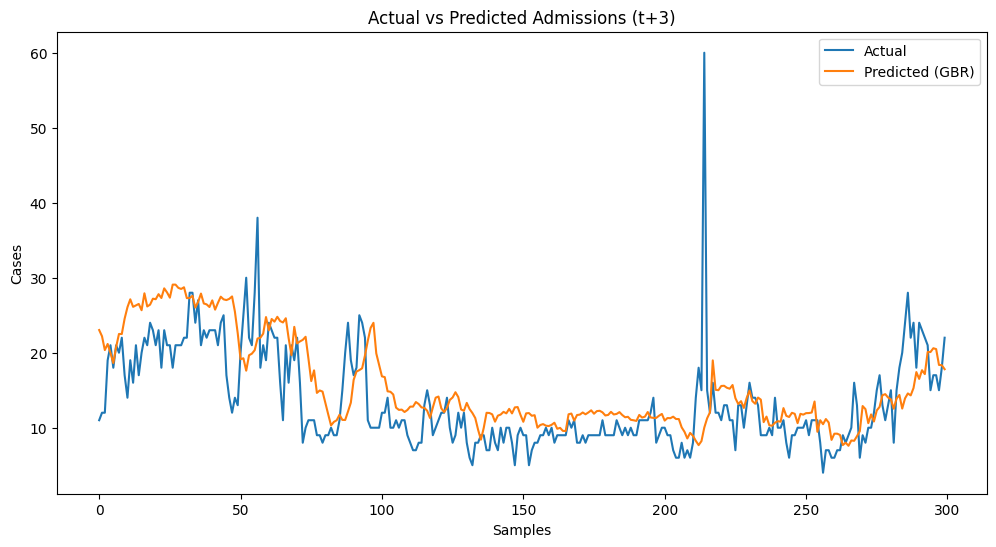

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(y_test.values[:300], label='Actual')
plt.plot(pred_gbr[:300], label='Predicted (GBR)')
plt.title('Actual vs Predicted Admissions (t+3)')
plt.xlabel('Samples')
plt.ylabel('Cases')
plt.legend()
plt.show()

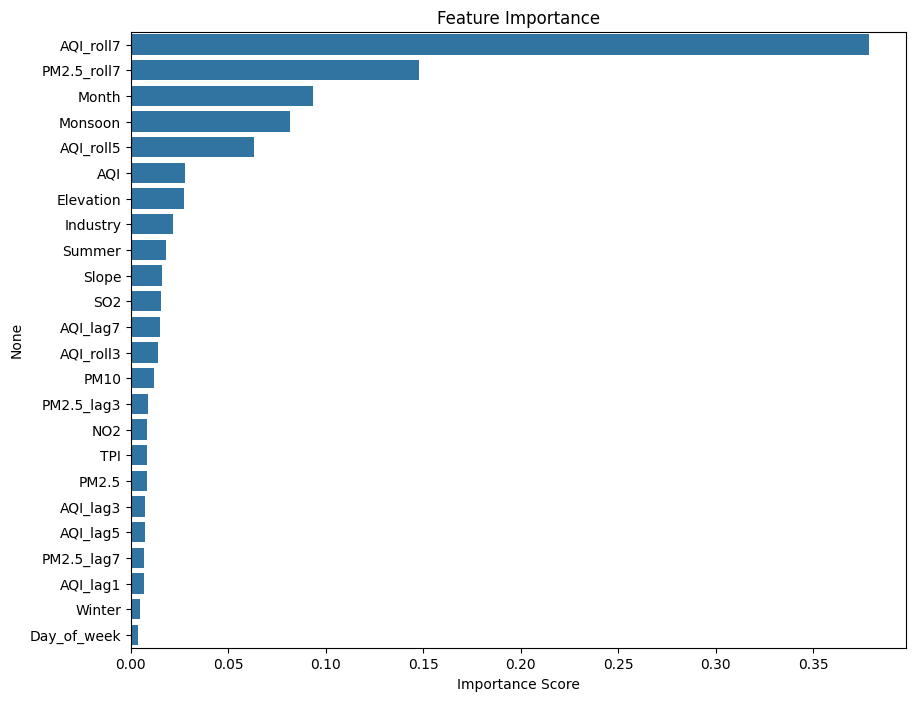

In [11]:
import seaborn as sns

importances = rf.feature_importances_
feat_imp = pd.Series(importances, index=features).sort_values(ascending=False)

plt.figure(figsize=(10,8))
sns.barplot(x=feat_imp.values, y=feat_imp.index)
plt.title("Feature Importance")
plt.xlabel("Importance Score")
plt.show()

In [12]:
results_df.to_csv("phase4_model_metrics.csv", index=False)

In [13]:
same_day_features = [
    'AQI', 'PM2.5', 'PM10', 'NO2', 'SO2',
    'Elevation', 'Slope', 'TPI',
    'Industry',
    'Month', 'Day_of_week', 'Winter', 'Summer', 'Monsoon'
]

In [14]:
X_train_sd = train_df[same_day_features]
X_test_sd  = test_df[same_day_features]

In [15]:
from sklearn.ensemble import HistGradientBoostingRegressor

gbr_sd = HistGradientBoostingRegressor(
    max_iter=200,
    max_depth=12,
    learning_rate=0.05,
    random_state=42
)

gbr_sd.fit(X_train_sd, y_train)
pred_sd = gbr_sd.predict(X_test_sd)

In [16]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_sd  = mean_absolute_error(y_test, pred_sd)
rmse_sd = np.sqrt(mean_squared_error(y_test, pred_sd))
r2_sd   = r2_score(y_test, pred_sd)

print("Same-Day Model Performance")
print("MAE :", mae_sd)
print("RMSE:", rmse_sd)
print("R²  :", r2_sd)

Same-Day Model Performance
MAE : 3.7913645099247573
RMSE: 5.000972364265311
R²  : 0.25085166273070214


In [17]:
print("\nLag-Aware Model Performance (from earlier)")
print(results_df)


Lag-Aware Model Performance (from earlier)
               Model       MAE      RMSE        R²
0  Linear Regression  4.222787  5.375311  0.134502
1      Random Forest  3.551317  4.769323  0.318647
2  Gradient Boosting  3.508736  4.703674  0.337275


In [18]:
lag_mae = results_df.loc[results_df['Model']=='Gradient Boosting','MAE'].values[0]

improvement = ((mae_sd - lag_mae) / mae_sd) * 100

print(f"\nLag-aware model improves MAE by {improvement:.2f}% over same-day model")


Lag-aware model improves MAE by 7.45% over same-day model


In [19]:
target_t3 = 'Cases_t_plus3'
target_t5 = 'Cases_t_plus5'

In [20]:
y_train_t3 = train_df[target_t3]
y_test_t3  = test_df[target_t3]

y_train_t5 = train_df[target_t5]
y_test_t5  = test_df[target_t5]

In [21]:
from sklearn.ensemble import HistGradientBoostingRegressor

# Model for t+3
gbr_t3 = HistGradientBoostingRegressor(
    max_iter=200,
    max_depth=12,
    learning_rate=0.05,
    random_state=42
)
gbr_t3.fit(X_train, y_train_t3)
pred_t3 = gbr_t3.predict(X_test)

# Model for t+5
gbr_t5 = HistGradientBoostingRegressor(
    max_iter=200,
    max_depth=12,
    learning_rate=0.05,
    random_state=42
)
gbr_t5.fit(X_train, y_train_t5)
pred_t5 = gbr_t5.predict(X_test)

In [22]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def eval_model(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    return [name, mae, rmse, r2]

results_horizon = []
results_horizon.append(eval_model("t+3 Forecast", y_test_t3, pred_t3))
results_horizon.append(eval_model("t+5 Forecast", y_test_t5, pred_t5))

horizon_df = pd.DataFrame(results_horizon, columns=["Horizon", "MAE", "RMSE", "R²"])
print(horizon_df)

        Horizon       MAE      RMSE        R²
0  t+3 Forecast  3.508736  4.703674  0.337275
1  t+5 Forecast  3.628621  4.840676  0.301698


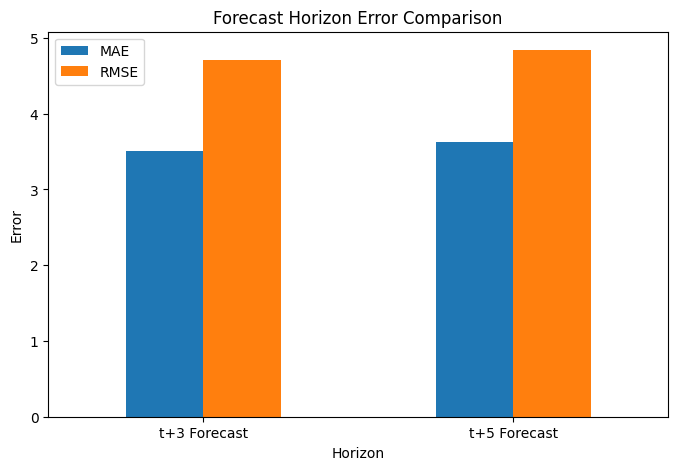

In [23]:
import matplotlib.pyplot as plt

horizon_df.set_index("Horizon")[["MAE","RMSE"]].plot(kind="bar", figsize=(8,5))
plt.title("Forecast Horizon Error Comparison")
plt.ylabel("Error")
plt.xticks(rotation=0)
plt.show()

In [24]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import HistGradientBoostingRegressor

param_grid = {
    'max_depth': [8, 12, 16],
    'learning_rate': [0.03, 0.05, 0.1],
    'max_iter': [100, 200]
}

In [25]:
gbr_base = HistGradientBoostingRegressor(random_state=42)

grid = GridSearchCV(
    estimator=gbr_base,
    param_grid=param_grid,
    cv=3,                  # 3-fold cross-validation
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=1
)

In [26]:
gbr_base = HistGradientBoostingRegressor(random_state=42)

grid = GridSearchCV(
    estimator=gbr_base,
    param_grid=param_grid,
    cv=3,                  # 3-fold cross-validation
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=1
)

In [27]:
grid.fit(X_train, y_train_t3)

Fitting 3 folds for each of 18 candidates, totalling 54 fits


,estimator,HistGradientB...ndom_state=42)
,param_grid,"{'learning_rate': [0.03, 0.05, ...], 'max_depth': [8, 12, ...], 'max_iter': [100, 200]}"
,scoring,'neg_mean_absolute_error'
,n_jobs,-1
,refit,True
,cv,3
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,loss,'squared_error'


In [28]:
print("Best Parameters:", grid.best_params_)

Best Parameters: {'learning_rate': 0.1, 'max_depth': 12, 'max_iter': 200}


In [29]:
best_gbr = grid.best_estimator_

pred_best = best_gbr.predict(X_test)

In [30]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae  = mean_absolute_error(y_test_t3, pred_best)
rmse = np.sqrt(mean_squared_error(y_test_t3, pred_best))
r2   = r2_score(y_test_t3, pred_best)

print("\nTuned Model Performance")
print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)


Tuned Model Performance
MAE : 3.4998827355438085
RMSE: 4.700777436893897
R²  : 0.338090994526708


In [31]:
print("\nBefore Tuning (Baseline GBR)")
print("MAE :", 3.508736)
print("RMSE:", 4.703674)
print("R²  :", 0.337275)

print("\nAfter Tuning")
print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)


Before Tuning (Baseline GBR)
MAE : 3.508736
RMSE: 4.703674
R²  : 0.337275

After Tuning
MAE : 3.4998827355438085
RMSE: 4.700777436893897
R²  : 0.338090994526708


In [32]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error
import numpy as np

In [33]:
X_all = df[features]
y_all = df['Cases_t_plus3']

In [34]:
tscv = TimeSeriesSplit(n_splits=5)

In [35]:
mae_scores = []

fold = 1
for train_idx, test_idx in tscv.split(X_all):
    X_tr, X_te = X_all.iloc[train_idx], X_all.iloc[test_idx]
    y_tr, y_te = y_all.iloc[train_idx], y_all.iloc[test_idx]
    
    model = HistGradientBoostingRegressor(
        max_depth=grid.best_params_['max_depth'],
        learning_rate=grid.best_params_['learning_rate'],
        max_iter=grid.best_params_['max_iter'],
        random_state=42
    )
    
    model.fit(X_tr, y_tr)
    pred = model.predict(X_te)
    
    mae = mean_absolute_error(y_te, pred)
    mae_scores.append(mae)
    
    print(f"Fold {fold} MAE: {mae:.4f}")
    fold += 1

Fold 1 MAE: 4.3110
Fold 2 MAE: 4.2456
Fold 3 MAE: 4.1477
Fold 4 MAE: 3.9841
Fold 5 MAE: 3.8745


In [36]:
print("\nTimeSeries CV Results")
print("MAE scores:", mae_scores)
print("Average MAE:", np.mean(mae_scores))
print("Std Dev:", np.std(mae_scores))


TimeSeries CV Results
MAE scores: [4.310992784989882, 4.245583025337036, 4.147676238249217, 3.9840663208357876, 3.874531401052002]
Average MAE: 4.112569954092786
Std Dev: 0.16215553313058229


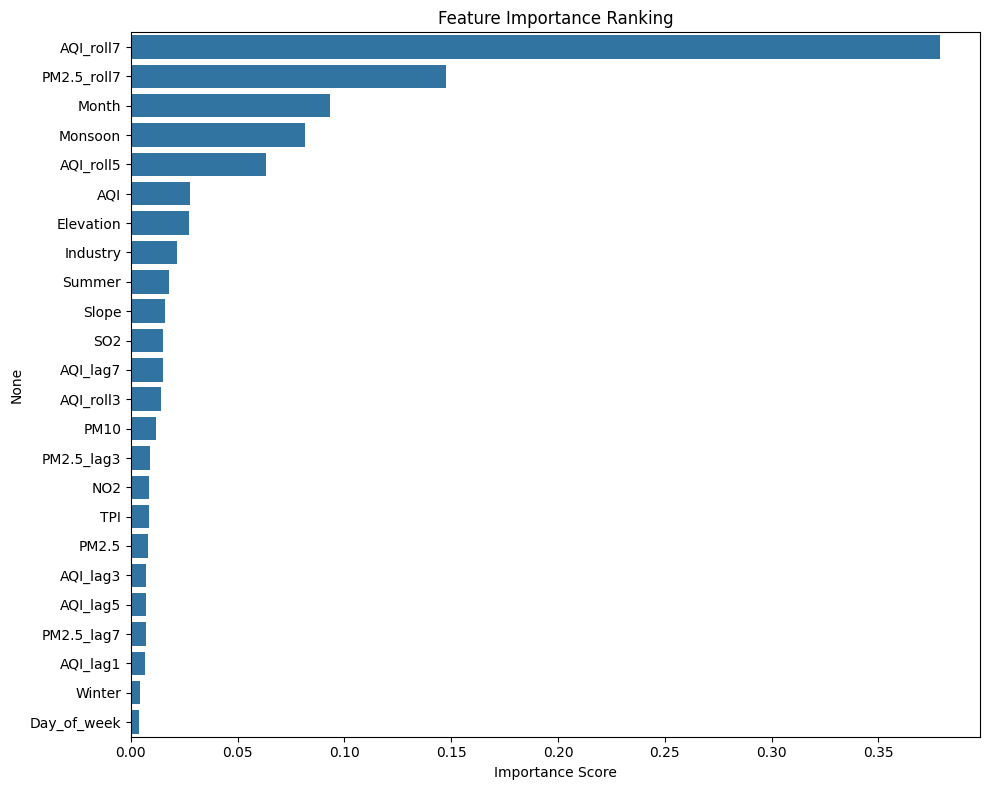

In [37]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

importances = rf.feature_importances_
feat_imp = pd.Series(importances, index=features).sort_values(ascending=False)

plt.figure(figsize=(10,8))
sns.barplot(x=feat_imp.values, y=feat_imp.index)
plt.title("Feature Importance Ranking")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

Category
Rolling Exposure      0.603247
Other                 0.273832
Same-Day Pollution    0.071254
Lag Exposure          0.051667
Name: Importance, dtype: float64


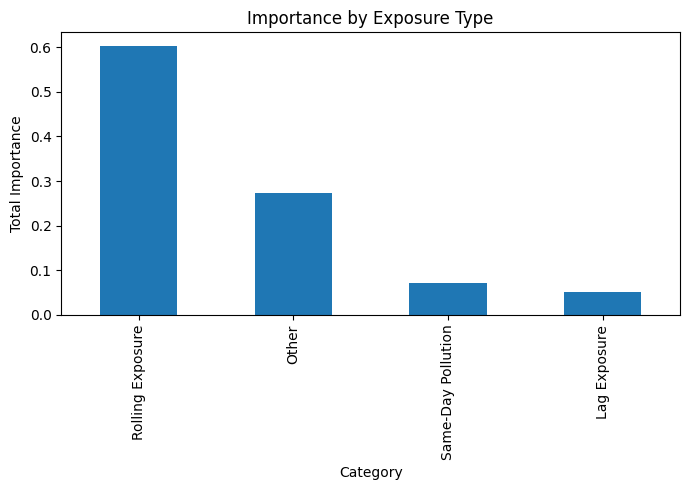

In [38]:
# Categorize features
pollution_base = ['AQI', 'PM2.5', 'PM10', 'NO2', 'SO2']
lags = ['AQI_lag1','AQI_lag3','AQI_lag5','AQI_lag7','PM2.5_lag3','PM2.5_lag7']
rolling = ['AQI_roll3','AQI_roll5','AQI_roll7','PM2.5_roll7']

feat_df = pd.DataFrame({'Feature': features, 'Importance': importances})

def get_category(f):
    if f in pollution_base: return 'Same-Day Pollution'
    if f in lags: return 'Lag Exposure'
    if f in rolling: return 'Rolling Exposure'
    return 'Other'

feat_df['Category'] = feat_df['Feature'].apply(get_category)

cat_imp = feat_df.groupby('Category')['Importance'].sum().sort_values(ascending=False)
print(cat_imp)

cat_imp.plot(kind='bar', figsize=(7,5))
plt.title("Importance by Exposure Type")
plt.ylabel("Total Importance")
plt.tight_layout()
plt.show()

Domain
Pollution     0.726168
Season        0.200690
Topography    0.051385
Industry      0.021757
Name: Importance, dtype: float64


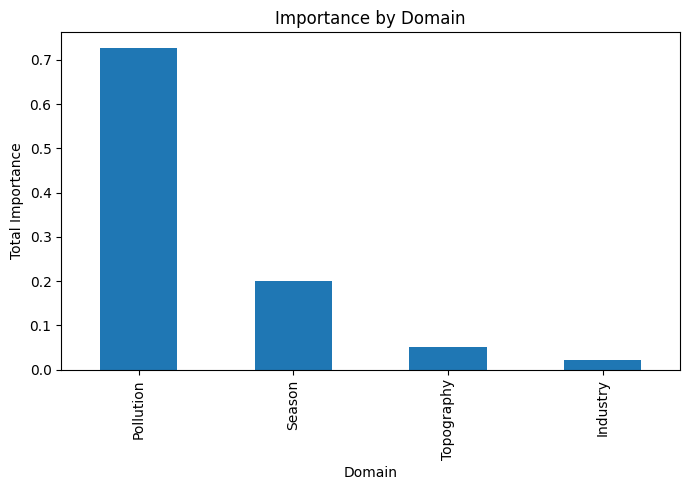

In [39]:
topography = ['Elevation','Slope','TPI']
industry = ['Industry']
season = ['Month','Day_of_week','Winter','Summer','Monsoon']

def get_domain(f):
    if f in pollution_base + lags + rolling: return 'Pollution'
    if f in topography: return 'Topography'
    if f in industry: return 'Industry'
    if f in season: return 'Season'
    return 'Other'

feat_df['Domain'] = feat_df['Feature'].apply(get_domain)

domain_imp = feat_df.groupby('Domain')['Importance'].sum().sort_values(ascending=False)
print(domain_imp)

domain_imp.plot(kind='bar', figsize=(7,5))
plt.title("Importance by Domain")
plt.ylabel("Total Importance")
plt.tight_layout()
plt.show()

In [40]:
# Predict on full dataset
df['pred_cases'] = best_gbr.predict(df[features])
df['error'] = abs(df['Cases_t_plus3'] - df['pred_cases'])

# Average error by city
city_risk = df.groupby('City')['error'].mean().sort_values(ascending=False)

print(city_risk.head(10))

City
Tiruppur            15.845110
Nandesari            8.238955
Pathardih            7.453410
Mandi Gobindgarh     7.023927
Byrnihat             6.945284
Buxar                6.790336
Saharsa              6.531535
Yamunanagar          6.273973
Ballabgarh           6.139077
Singrauli            6.121889
Name: error, dtype: float64
